# ATHENA CAMM Hackathon 01
## Boundary Detection + Atom Finding

**September 2026**

A scientific algorithm should not only work once. It should be **explainable, testable, fast, consistent, and robust**.

### Challenge 1 — Boundary Detection
- Dataset: **SiSb**
- Input: **12 HAADF-STEM images**
- Goal: detect the crystalline–amorphous boundary

### Challenge 2 — Atom Finding
- Dataset: **YBCO**
- Input: atomic-resolution STEM images
- Goal: return atomic-column coordinates

All helper functions are kept in:

```text
utils.py
```

The notebook stays focused on the two functions you are asked to improve.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kbarakati/athena_camm_hackathon/blob/k4my4r/docs/day_16_11092026/boundary_detection.ipynb)

## 1. Setup

In [ ]:
 %pip install -q pyTEMlib ipympl

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.7/859.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.7/135.7 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.0/128.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 71.4 MB/s eta 0:00:00
   ━━━━━━

In [ ]:
# Download only the files needed for this challenge
!git clone -q --filter=blob:none --no-checkout -b k4my4r \
  https://github.com/kbarakati/athena_camm_hackathon.git athena

%cd athena
!git sparse-checkout init --cone
!git sparse-checkout set docs/day_16_11092026
!git checkout -q

%cd docs/day_16_11092026

/content/athena
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 33 (delta 0), reused 0 (delta 0), pack-reused 31 (from 1)
Receiving objects: 100% (33/33), 112.25 MiB | 24.29 MiB/s, done.
/content/athena/docs/day_16_11092026


In [ ]:
import sys
sys.path.append('.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage

from utils import (
    resolve_data_dir,
    list_emd_files,
    robust_normalize,
    load_haadf,
    show_image_grid,
    plot_ground_truth_grid,
    plot_boundary_result,
    evaluate_against_ground_truth,
    summarize_accuracy,
    evaluate_robustness,
    summarize_robustness,
    evaluate_speed,
    summarize_speed,
    plot_atom_result,
    validate_atom_output,
    atom_repeatability,
    atom_noise_robustness,
    atom_photometric_robustness,
)

copied from /usr/local/lib/python3.13/dist-packages/pyTEMlib/data: xrays_X_section_300kV.json
copied from /usr/local/lib/python3.13/dist-packages/pyTEMlib/data: xrays_X_section_200kV.json
copied from /usr/local/lib/python3.13/dist-packages/pyTEMlib/data: k_factors_Bruker_15keV.json
copied from /usr/local/lib/python3.13/dist-packages/pyTEMlib/data: k_factors_Thermo_60keV.json
copied from /usr/local/lib/python3.13/dist-packages/pyTEMlib/data: k_factors_Thermo_200keV.json
copied from /usr/local/lib/python3.13/dist-packages/pyTEMlib/data: xrays_X_section_60kV.json
copied from /usr/local/lib/python3.13/dist-packages/pyTEMlib/data: xrays_X_section_100kV.json


In [ ]:
DATA_DIR = resolve_data_dir()

SISB_DIR = DATA_DIR / "SiSb"
YBCO_DIR = DATA_DIR / "YBCO"
GT_DIR = DATA_DIR / "SiSb_ground_truth"

print("DATA_DIR:", DATA_DIR)
print("SiSb:", SISB_DIR.exists())
print("YBCO:", YBCO_DIR.exists())
print("SiSb ground truth:", GT_DIR.exists())

DATA_DIR: /content/athena/docs/day_16_11092026/data
SiSb: True
YBCO: True
SiSb ground truth: True


# Challenge 1 — Boundary Detection

## Goal

Write:

```python
boundary = detect_boundary(image)
```

The function must return a **2D boolean array with the same shape as the input image**.

`True` means that pixel belongs to the predicted crystalline–amorphous boundary.

## 2. Load the SiSb challenge images

In [ ]:
all_sisb_files = list_emd_files(SISB_DIR)

N_SISB = 12
sisb_files = all_sisb_files[:N_SISB]

sisb_images = [
    load_haadf(file)
    for file in sisb_files
]

sisb_titles = [
    file.stem.split("-")[0].strip()
    for file in sisb_files
]

print(f"Using {len(sisb_files)} SiSb images")

Using 12 SiSb images


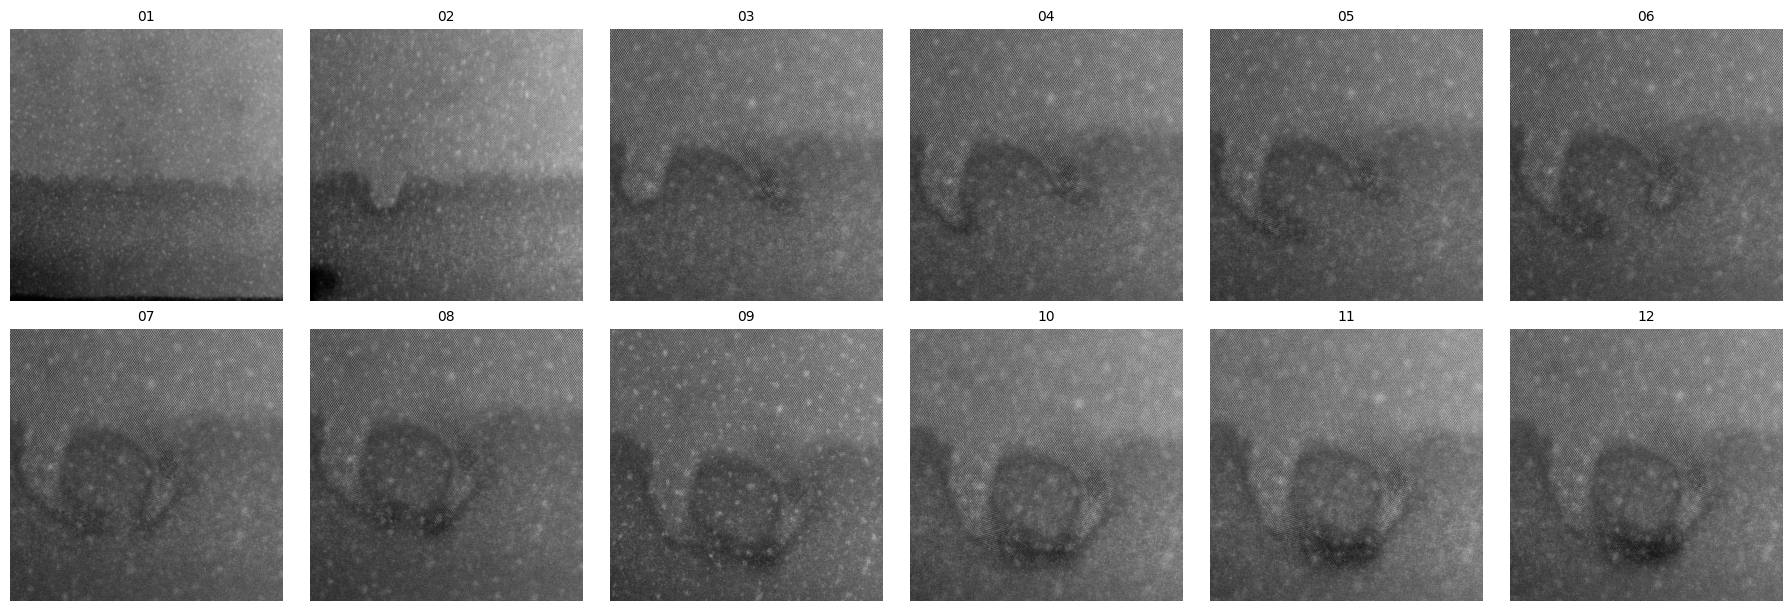

In [ ]:
show_image_grid(
    sisb_images,
    titles=sisb_titles,
    rows=2,
)

### Human ground truth

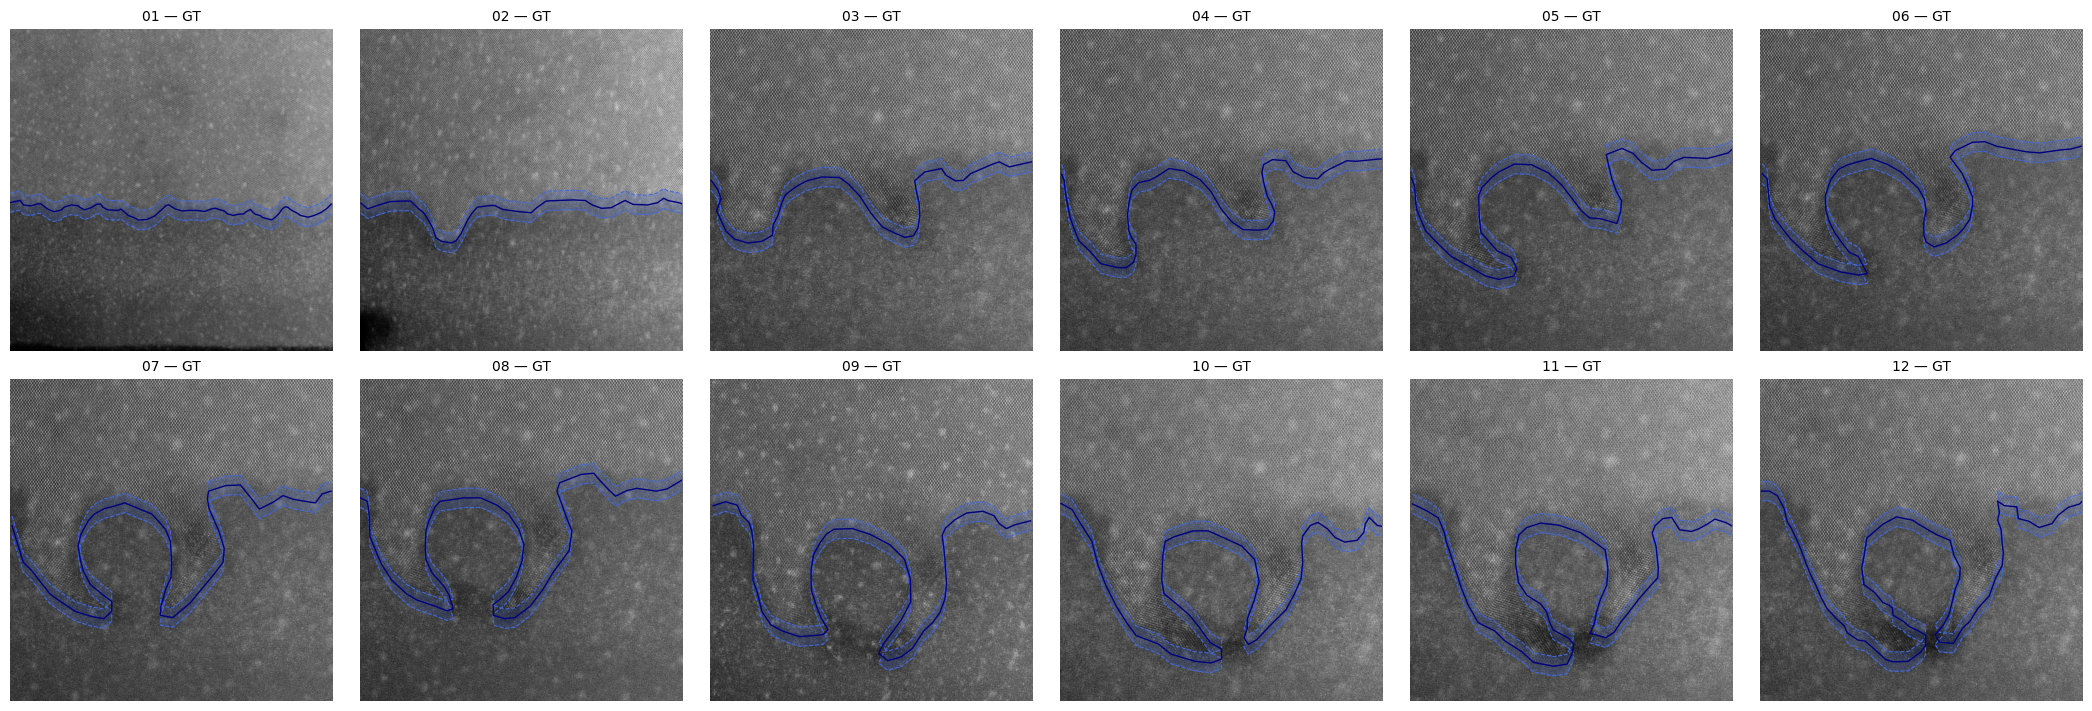

In [ ]:
plot_ground_truth_grid(
    sisb_images,
    sisb_files,
    sisb_titles,
    GT_DIR,
    rows=2,
)

## 3. Build your boundary detector

A simple texture-based baseline is provided.

You may completely replace the code between the two markers.  
Do **not** change the function name, input, or required output format.

In [ ]:
def detect_boundary(image):

    # ============================================================
    # ===== YOUR CODE START — CHANGE CODE BELOW THIS LINE =====
    # ============================================================

    # 1. Normalize
    x = robust_normalize(image)

    # 2. Estimate local texture using local variance
    sigma_texture = 7

    local_mean = ndimage.gaussian_filter(
        x,
        sigma=sigma_texture
    )

    local_mean_squared = ndimage.gaussian_filter(
        x**2,
        sigma=sigma_texture
    )

    local_variance = np.maximum(
        local_mean_squared - local_mean**2,
        0
    )

    # 3. Smooth the texture map
    texture = ndimage.gaussian_filter(
        local_variance,
        sigma=1
    )

    # 4. Separate the two texture regimes
    threshold = np.median(texture)
    phase_mask = texture > threshold

    # 5. Clean the phase segmentation
    phase_mask = ndimage.binary_opening(
        phase_mask,
        iterations=2
    )

    phase_mask = ndimage.binary_closing(
        phase_mask,
        iterations=1
    )

    # 6. Extract the interface
    dilated = ndimage.binary_dilation(
        phase_mask,
        iterations=1
    )

    eroded = ndimage.binary_erosion(
        phase_mask,
        iterations=1
    )

    boundary = dilated ^ eroded

    # ============================================================
    # ===== YOUR CODE END — DO NOT CHANGE CODE BELOW HERE =====
    # ============================================================

    return boundary.astype(bool)

## 4. Test one image visually

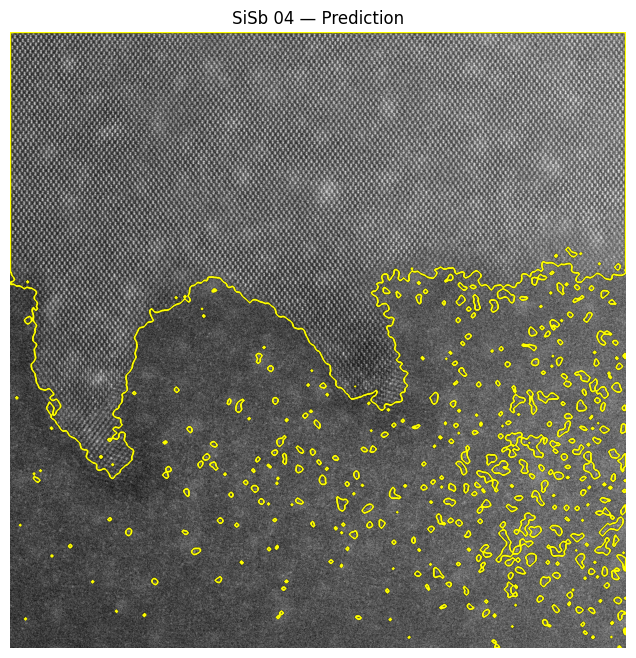

In [ ]:
example_index = 3

image = sisb_images[example_index]
boundary = detect_boundary(image)

plot_boundary_result(
    image,
    boundary,
    title=f"SiSb {sisb_titles[example_index]} — Prediction",
)

## 5. Challenge 1 evaluation

We evaluate only three things:

### 1. Accuracy against human ground truth
Predictions are compared with the hand-drawn boundary using a spatial tolerance. Exact single-pixel agreement is not required.

Primary metric: **F1 @ 5 px tolerance**

### 2. Robustness
The same detector is tested after controlled perturbations:
- Gaussian noise
- Gaussian blur
- brightness change
- contrast change
- inclined intensity background

Every perturbed prediction is compared with the **same human ground truth**.

### 3. Speed
Only `detect_boundary(image)` is timed. File loading, plotting, and scoring are excluded.

### Test 1 — Accuracy against ground truth

In [ ]:
accuracy_results = evaluate_against_ground_truth(
    detect_boundary,
    sisb_images,
    sisb_files,
    sisb_titles,
    GT_DIR,
    tolerance_px=10,
)

accuracy_results

,image,precision,recall,f1,mean_pred_to_gt_distance,mean_gt_to_pred_distance,mean_symmetric_boundary_error
0,01,0.000000,0.000000,0.000000,553.454174,50.357116,301.905645
1,02,0.003970,0.035194,0.007136,478.345666,49.879208,264.112437
2,03,0.019030,0.150754,0.033794,380.337147,28.874004,204.605576
3,04,0.014422,0.119235,0.025732,372.227003,29.417843,200.822423
4,05,0.021593,0.192630,0.038833,371.144156,27.774909,199.459533
5,06,0.026246,0.261549,0.047705,336.455604,22.699630,179.577617
6,07,0.030112,0.304748,0.054808,328.143347,24.448067,176.295707
7,08,0.026318,0.310725,0.048527,331.464651,20.377279,175.920965
8,09,0.024270,0.157822,0.042070,262.490587,28.588062,145.539325
9,10,0.011708,0.039072,0.018018,336.856534,65.610758,201.233646


In [ ]:
summarize_accuracy(
    accuracy_results
)

,Clean boundary accuracy
mean_precision,0.018486
mean_recall,0.145252
mean_f1,0.032233
mean_boundary_error_px,199.584051


### Test 2 — Robustness

In [ ]:
robustness_results = evaluate_robustness(
    detect_boundary,
    sisb_images,
    sisb_files,
    sisb_titles,
    GT_DIR,
    tolerance_px=5,
    max_images=4,
)

robustness_summary = summarize_robustness(
    robustness_results
)

robustness_summary

,condition,mean_f1,std_f1,mean_precision,mean_recall,mean_boundary_error_px,f1_drop_from_clean
0,Clean,0.017339,0.013305,0.010161,0.074238,208.823377,0.000000
1,Gaussian noise 5%,0.017876,0.014308,0.010356,0.083201,206.676882,-0.000536
2,Gaussian blur sigma=1,0.028224,0.024044,0.017263,0.108772,187.181715,-0.010885
3,Brightness +10%,0.017339,0.013305,0.010161,0.074238,208.823377,0.000000
4,Contrast -20%,0.017339,0.013305,0.010161,0.074238,208.823377,0.000000
5,Intensity gradient 20%,0.018795,0.015322,0.011040,0.080091,203.260303,-0.001456


Interpretation:

- `mean_f1`: accuracy under that condition
- `mean_boundary_error_px`: average symmetric distance to the human boundary
- `f1_drop_from_clean`: performance lost relative to the clean images

**Smaller F1 drop is better.**

### Test 3 — Speed

In [ ]:
speed_results = evaluate_speed(
    detect_boundary,
    sisb_images,
    repeats=5,
)

summarize_speed(
    speed_results
)

,Speed
mean_seconds_per_image,1.755914
median_seconds_per_image,1.555242
slowest_seconds,3.465324
images_per_second,0.569504


# Challenge 2 — Atom Finding in YBCO

## Goal

Write:

```python
positions = find_atoms(image)
```

The function must return a NumPy array of shape `(N, 2)`.

Each row is:

```text
[y, x]
```

in pixel coordinates.

## 6. Load YBCO

Found 3 YBCO images


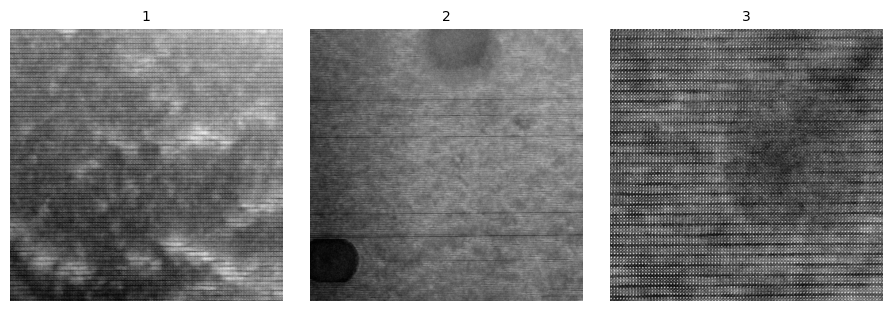

In [ ]:
ybco_files = list_emd_files(YBCO_DIR)

ybco_images = [
    load_haadf(file)
    for file in ybco_files
]

ybco_titles = [
    file.stem
    for file in ybco_files
]

print(f"Found {len(ybco_images)} YBCO images")

if ybco_images:
    show_image_grid(
        ybco_images,
        titles=[
            str(i + 1)
            for i in range(len(ybco_images))
        ],
        rows=1 if len(ybco_images) > 1 else 1,
    )

## 7. Build your atom finder

A simple local-maximum baseline is provided.

You may completely replace the code between the two markers.

In [ ]:
def find_atoms(image):

    # ============================================================
    # ===== YOUR CODE START — CHANGE CODE BELOW THIS LINE =====
    # ============================================================

    # 1. Normalize
    x = robust_normalize(image)

    # 2. Smooth
    smooth = ndimage.gaussian_filter(
        x,
        sigma=1.0
    )

    # 3. Find local maxima
    neighborhood = 5

    local_max = (
        smooth
        == ndimage.maximum_filter(
            smooth,
            size=neighborhood,
            mode="reflect",
        )
    )

    # 4. Keep only bright maxima
    intensity_threshold = np.percentile(
        smooth,
        97.0,
    )

    peaks = (
        local_max
        & (smooth >= intensity_threshold)
    )

    # 5. Convert peaks to [y, x]
    positions = np.argwhere(peaks)

    # ============================================================
    # ===== YOUR CODE END — DO NOT CHANGE CODE BELOW HERE =====
    # ============================================================

    return np.asarray(
        positions
    ).reshape(-1, 2).astype(float)

## 8. Test one YBCO image visually

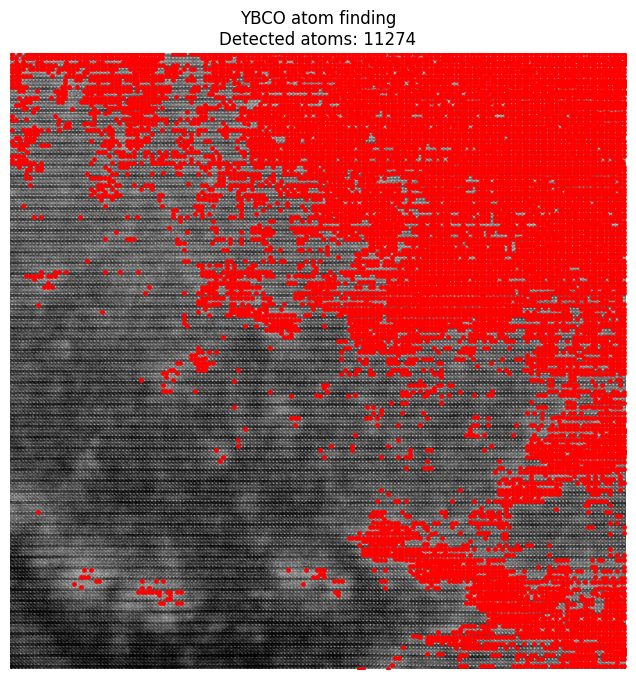

In [ ]:
if ybco_images:

    atom_example_index = 0

    atom_positions = find_atoms(
        ybco_images[atom_example_index]
    )

    validate_atom_output(
        ybco_images[atom_example_index],
        atom_positions,
    )

    plot_atom_result(
        ybco_images[atom_example_index],
        atom_positions,
        title="YBCO atom finding",
    )

## 9. Challenge 2 engineering tests

Until atom ground truth is added, these measure **consistency and robustness**, not true atom-detection accuracy.

In [ ]:
if ybco_images:
    atom_noise_results = atom_noise_robustness(
        find_atoms,
        ybco_images,
        noise_levels=(0.01, 0.03, 0.05, 0.10),
        tolerance=2.0,
    )

atom_noise_results

,noise_level_fraction,mean_F1_vs_clean,min_F1_vs_clean,mean_count_ratio
0,0.01,0.984734,0.971827,0.999115
1,0.03,0.955088,0.914307,0.999233
2,0.05,0.924838,0.859233,1.001870
3,0.10,0.850811,0.730625,1.014435


In [ ]:
if ybco_images:
    atom_photometric_results = atom_photometric_robustness(
        find_atoms,
        ybco_images,
        tolerance=2.0,
    )

atom_photometric_results

,gain,offset_fraction,mean_F1_vs_clean
0,0.8,0.0,1.0
1,1.2,0.0,1.0
2,1.0,0.1,1.0


In [ ]:
if ybco_images:

    atom_speed_results = evaluate_speed(
        find_atoms,
        ybco_images,
        repeats=5,
    )

summarize_speed(
        atom_speed_results
    )

,Speed
mean_seconds_per_image,0.601477
median_seconds_per_image,0.600214
slowest_seconds,0.625681
images_per_second,1.662575


# 10. Reflection

At the end of the session, be ready to explain:

1. What approach did you use?
2. Which parameters matter most?
3. Where does it fail?
4. What would you improve next?
5. If AI helped write code, what did it generate?
6. What did you personally change?

> A good scientific algorithm is not just one that gives a nice picture.  
> You should be able to explain **how accurate, robust, and fast it is**.

In [ ]:
# Challenge 1 — Experimental Boundary Detection

#Investigate which image features best reveal the crystalline–amorphous interface:

#- Regional mean intensity
#- Local contrast at multiple spatial scales
#- Local contrast after broad-scale intensity subtraction
#- Local high-pass energy

#Feature maps are inspected before assigning phase labels or extracting a boundary.
#The original challenge functions remain unchanged.

In [ ]:
# ============================================================
# BLOCK 1 — CHALLENGE 1 SETTINGS
# ============================================================

import time
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage


# ------------------------------------------------------------
# Feature extraction
# ------------------------------------------------------------

# Removes broad illumination/intensity variation
C1_BACKGROUND_SIGMA = 20.0

# Spatial scale used for local contrast
C1_LOCAL_SIGMA = 6.0

# Mild smoothing of the contrast feature
C1_FEATURE_SMOOTH_Y = 1.5
C1_FEATURE_SMOOTH_X = 2.5


# ------------------------------------------------------------
# Boundary search
# ------------------------------------------------------------

# Prevent boundary from being placed directly on top/bottom frame
C1_TOP_MARGIN_FRAC = 0.03
C1_BOTTOM_MARGIN_FRAC = 0.03

# Maximum allowed vertical movement between neighboring columns
C1_MAX_STEP = 10

# Penalty for unnecessary column-to-column movement
C1_SMOOTH_LAMBDA = 0.30

# Weight placed on the actual local transition
C1_EDGE_WEIGHT = 0.30


# ------------------------------------------------------------
# Final local refinement
# ------------------------------------------------------------

# Search a few pixels around the coarse path for the strongest edge
C1_REFINE_RADIUS = 5

# Remove tiny one-column spikes
C1_PATH_MEDIAN_SIZE = 5

# Very mild final smoothing
C1_PATH_GAUSSIAN_SIGMA = 1.25


# ------------------------------------------------------------
# Required notebook objects
# ------------------------------------------------------------

required_objects = [
    "sisb_images",
    "robust_normalize",
]

missing_objects = [
    name
    for name in required_objects
    if name not in globals()
]

if missing_objects:
    raise RuntimeError(
        "Run the notebook's original loading/import cells first. "
        f"Missing: {missing_objects}"
    )

if len(sisb_images) == 0:
    raise RuntimeError(
        "sisb_images is empty."
    )


print(
    f"Challenge 1 ready: "
    f"{len(sisb_images)} SiSb images loaded."
)

for i, image in enumerate(sisb_images):
    print(
        f"Image {i:02d}: "
        f"shape = {np.asarray(image).shape}"
    )

Challenge 1 ready: 12 SiSb images loaded.
Image 00: shape = (2048, 2048)
Image 01: shape = (2048, 2048)
Image 02: shape = (2048, 2048)
Image 03: shape = (2048, 2048)
Image 04: shape = (2048, 2048)
Image 05: shape = (2048, 2048)
Image 06: shape = (2048, 2048)
Image 07: shape = (2048, 2048)
Image 08: shape = (2048, 2048)
Image 09: shape = (2048, 2048)
Image 10: shape = (2048, 2048)
Image 11: shape = (2048, 2048)


In [ ]:
# ============================================================
# BLOCK 2 — ROBUST OTSU THRESHOLD
# ============================================================

def c1_otsu_threshold(values, bins=256):
    """
    Compute an automatic Otsu threshold.

    The histogram is restricted to the 1st-99th percentile
    range so extreme pixels do not dominate the result.
    """

    values = np.asarray(
        values,
        dtype=np.float64
    )

    finite = values[
        np.isfinite(values)
    ]

    if finite.size == 0:
        raise ValueError(
            "Feature map contains no finite values."
        )

    lo, hi = np.percentile(
        finite,
        [1, 99]
    )

    if hi <= lo:
        return float(
            np.median(finite)
        )

    clipped = np.clip(
        finite,
        lo,
        hi
    )

    hist, edges = np.histogram(
        clipped,
        bins=bins,
        range=(lo, hi)
    )

    hist = hist.astype(
        np.float64
    )

    centers = 0.5 * (
        edges[:-1] + edges[1:]
    )

    probabilities = (
        hist
        / max(
            hist.sum(),
            1.0
        )
    )

    weight_left = np.cumsum(
        probabilities
    )

    weight_right = (
        1.0 - weight_left
    )

    mean_left_num = np.cumsum(
        probabilities * centers
    )

    total_mean = (
        mean_left_num[-1]
    )

    mean_left = (
        mean_left_num
        / np.maximum(
            weight_left,
            1e-12
        )
    )

    mean_right = (
        total_mean - mean_left_num
    ) / np.maximum(
        weight_right,
        1e-12
    )

    between_class_variance = (
        weight_left
        * weight_right
        * (
            mean_left
            - mean_right
        ) ** 2
    )

    # Final histogram bin cannot form two classes
    index = int(
        np.argmax(
            between_class_variance[:-1]
        )
    )

    return float(
        centers[index]
    )

In [ ]:
# ============================================================
# BLOCK 2 — ROBUST OTSU THRESHOLD
# ============================================================

def c1_otsu_threshold(values, bins=256):
    """
    Compute an automatic Otsu threshold.

    The histogram is restricted to the 1st-99th percentile
    range so extreme pixels do not dominate the result.
    """

    values = np.asarray(
        values,
        dtype=np.float64
    )

    finite = values[
        np.isfinite(values)
    ]

    if finite.size == 0:
        raise ValueError(
            "Feature map contains no finite values."
        )

    lo, hi = np.percentile(
        finite,
        [1, 99]
    )

    if hi <= lo:
        return float(
            np.median(finite)
        )

    clipped = np.clip(
        finite,
        lo,
        hi
    )

    hist, edges = np.histogram(
        clipped,
        bins=bins,
        range=(lo, hi)
    )

    hist = hist.astype(
        np.float64
    )

    centers = 0.5 * (
        edges[:-1] + edges[1:]
    )

    probabilities = (
        hist
        / max(
            hist.sum(),
            1.0
        )
    )

    weight_left = np.cumsum(
        probabilities
    )

    weight_right = (
        1.0 - weight_left
    )

    mean_left_num = np.cumsum(
        probabilities * centers
    )

    total_mean = (
        mean_left_num[-1]
    )

    mean_left = (
        mean_left_num
        / np.maximum(
            weight_left,
            1e-12
        )
    )

    mean_right = (
        total_mean - mean_left_num
    ) / np.maximum(
        weight_right,
        1e-12
    )

    between_class_variance = (
        weight_left
        * weight_right
        * (
            mean_left
            - mean_right
        ) ** 2
    )

    # Final histogram bin cannot form two classes
    index = int(
        np.argmax(
            between_class_variance[:-1]
        )
    )

    return float(
        centers[index]
    )

In [ ]:
# ============================================================
# BLOCK 3 — LOCAL CONTRAST FEATURE
# ============================================================

def c1_local_mean_std(values, sigma):
    """
    Gaussian-weighted local mean and local standard deviation.
    """

    values = np.asarray(
        values,
        dtype=np.float64
    )

    local_mean = ndimage.gaussian_filter(
        values,
        sigma=sigma,
        mode="reflect"
    )

    local_mean_sq = ndimage.gaussian_filter(
        values ** 2,
        sigma=sigma,
        mode="reflect"
    )

    local_variance = np.maximum(
        local_mean_sq
        - local_mean ** 2,
        0.0
    )

    local_std = np.sqrt(
        local_variance
    )

    return (
        local_mean,
        local_std
    )


def c1_make_feature(image):
    """
    Convert one HAADF-STEM image into the local-contrast
    feature used for boundary detection.
    """

    image = np.asarray(
        image,
        dtype=np.float64
    )

    if image.ndim != 2:
        raise ValueError(
            "Challenge 1 expects a 2-D grayscale image."
        )

    if image.size == 0:
        raise ValueError(
            "Image is empty."
        )

    if not np.isfinite(image).all():
        raise ValueError(
            "Image contains NaN or infinite values."
        )

    # --------------------------------------------------------
    # 1. Robust normalization supplied by notebook
    # --------------------------------------------------------

    x = np.asarray(
        robust_normalize(
            image.copy()
        ),
        dtype=np.float64
    )

    # --------------------------------------------------------
    # 2. Remove broad spatial intensity variation
    # --------------------------------------------------------

    background = ndimage.gaussian_filter(
        x,
        sigma=C1_BACKGROUND_SIGMA,
        mode="reflect"
    )

    residual = (
        x - background
    )

    # --------------------------------------------------------
    # 3. Local contrast
    # --------------------------------------------------------

    _, local_std = c1_local_mean_std(
        residual,
        C1_LOCAL_SIGMA
    )

    # --------------------------------------------------------
    # 4. Mild smoothing
    #
    # Suppress lattice-scale noise while preserving the
    # large curved crystal/amorphous interface.
    # --------------------------------------------------------

    feature = ndimage.gaussian_filter(
        local_std,
        sigma=(
            C1_FEATURE_SMOOTH_Y,
            C1_FEATURE_SMOOTH_X
        ),
        mode="reflect"
    )

    return (
        x,
        residual,
        feature
    )

In [ ]:
# ============================================================
# BLOCK 5 — HYSTERESIS 2-D PHASE SEGMENTATION
# ============================================================

def c1_segment_phases(feature):
    """
    Segment the crystalline phase using hysteresis thresholding.

    Strong crystal:
        clearly above the automatic Otsu threshold

    Weak crystal:
        slightly below Otsu, but retained when continuously
        connected to the macroscopic crystalline region

    This preserves narrow crystalline protrusions / prongs
    that were being removed by hard thresholding + opening.
    """

    feature = np.asarray(
        feature,
        dtype=np.float64
    )

    h, w = feature.shape

    # --------------------------------------------------------
    # 1. Automatic central threshold
    # --------------------------------------------------------

    threshold = c1_otsu_threshold(
        feature
    )

    # Use the feature spread to define a lower hysteresis
    # threshold in a scale-independent way.
    q25, q75 = np.percentile(
        feature,
        [25, 75]
    )

    spread = max(
        float(q75 - q25),
        1e-8
    )

    # --------------------------------------------------------
    # 2. Hysteresis thresholds
    # --------------------------------------------------------

    # Pixels above this are definite crystal candidates.
    strong_threshold = threshold

    # Pixels slightly below Otsu may still belong to crystal
    # if connected to the main crystalline region.
    weak_threshold = (
        threshold
        - 0.35 * spread
    )

    strong_mask = (
        feature >= strong_threshold
    )

    weak_mask = (
        feature >= weak_threshold
    )

    # --------------------------------------------------------
    # 3. VERY mild closing only
    #
    # Do NOT use binary opening here.
    # Opening was cutting off narrow crystal prongs.
    # --------------------------------------------------------

    weak_mask = ndimage.binary_closing(
        weak_mask,
        structure=np.ones(
            (3, 3),
            dtype=bool
        ),
        iterations=1
    )

    # --------------------------------------------------------
    # 4. Determine which side contains crystal
    # --------------------------------------------------------

    orientation = c1_determine_orientation(
        feature
    )

    crystal_on_top = orientation[
        "crystal_on_top"
    ]

    connectivity = np.ones(
        (3, 3),
        dtype=bool
    )

    seed_depth = max(
        3,
        int(
            round(
                0.06 * h
            )
        )
    )

    # --------------------------------------------------------
    # 5. Seed the macroscopic crystalline region
    #
    # Start from strong pixels on the crystalline side.
    # --------------------------------------------------------

    crystal_seed = np.zeros_like(
        strong_mask,
        dtype=bool
    )

    if crystal_on_top:

        crystal_seed[
            :seed_depth,
            :
        ] = strong_mask[
            :seed_depth,
            :
        ]

    else:

        crystal_seed[
            h - seed_depth:,
            :
        ] = strong_mask[
            h - seed_depth:,
            :
        ]

    # --------------------------------------------------------
    # 6. Safety fallback
    #
    # If unusually few pixels satisfy the strong threshold in
    # the seed band, use the weak mask there instead.
    # --------------------------------------------------------

    if np.count_nonzero(
        crystal_seed
    ) < max(
        10,
        int(0.01 * w * seed_depth)
    ):

        crystal_seed[:] = False

        if crystal_on_top:

            crystal_seed[
                :seed_depth,
                :
            ] = weak_mask[
                :seed_depth,
                :
            ]

        else:

            crystal_seed[
                h - seed_depth:,
                :
            ] = weak_mask[
                h - seed_depth:,
                :
            ]

    # --------------------------------------------------------
    # 7. Hysteresis propagation
    #
    # This is the important step.
    #
    # Start from definite crystal and allow it to grow through
    # slightly weaker contrast as long as it stays connected.
    # --------------------------------------------------------

    crystal_region = ndimage.binary_propagation(
        crystal_seed,
        structure=connectivity,
        mask=weak_mask
    )

    # --------------------------------------------------------
    # 8. Remove only tiny isolated defects
    #
    # We deliberately DO NOT use morphological opening.
    # --------------------------------------------------------

    labels, n_labels = ndimage.label(
        crystal_region,
        structure=connectivity
    )

    if n_labels > 1:

        # Normally propagation already gives a connected region,
        # but this protects against unusual seed configurations.
        component_sizes = np.bincount(
            labels.ravel()
        )

        component_sizes[0] = 0

        largest = int(
            np.argmax(
                component_sizes
            )
        )

        crystal_region = (
            labels == largest
        )

    # --------------------------------------------------------
    # 9. Opposite phase
    # --------------------------------------------------------

    amorphous_region = (
        ~crystal_region
    )

    return {
        "threshold":
            float(threshold),

        "weak_threshold":
            float(weak_threshold),

        "orientation":
            orientation,

        "crystal_region":
            crystal_region.astype(bool),

        "amorphous_region":
            amorphous_region.astype(bool),

        # Keep this key because Block 8 already expects it.
        "raw_high_contrast":
            strong_mask.astype(bool),

        "weak_high_contrast":
            weak_mask.astype(bool),
    }

In [ ]:
# ============================================================
# BLOCK 6 — EXTRACT THE INTERNAL PHASE INTERFACE
# ============================================================

def c1_extract_main_interface(
    crystal_region,
    amorphous_region
):
    """
    Extract only the internal interface between the two
    macroscopic phases.

    This does NOT trace the exterior border of the image.
    """

    crystal_region = np.asarray(
        crystal_region,
        dtype=bool
    )

    amorphous_region = np.asarray(
        amorphous_region,
        dtype=bool
    )

    if (
        crystal_region.shape
        != amorphous_region.shape
    ):
        raise ValueError(
            "Phase masks must have identical shapes."
        )

    h, w = crystal_region.shape

    connectivity = np.ones(
        (3, 3),
        dtype=bool
    )

    # --------------------------------------------------------
    # One-pixel shell on the amorphous side of the crystal
    # --------------------------------------------------------

    interface = (
        ndimage.binary_dilation(
            crystal_region,
            structure=connectivity,
            iterations=1
        )
        &
        amorphous_region
    )

    # Top/bottom frame cannot be the desired interface.
    interface[
        0,
        :
    ] = False

    interface[
        -1,
        :
    ] = False

    # --------------------------------------------------------
    # Connected-component analysis
    #
    # We want the component spanning the greatest fraction
    # of the image horizontally.
    # --------------------------------------------------------

    labels, n_labels = ndimage.label(
        interface,
        structure=connectivity
    )

    if n_labels == 0:

        return interface

    best_label = None
    best_score = -np.inf

    for label_id in range(
        1,
        n_labels + 1
    ):

        y, x = np.nonzero(
            labels == label_id
        )

        if x.size == 0:
            continue

        x_span = (
            int(x.max())
            - int(x.min())
        )

        size = x.size

        touches_left = (
            x.min() <= 2
        )

        touches_right = (
            x.max() >= w - 3
        )

        # Strongly prefer a component that spans the image.
        score = (
            float(x_span)
            +
            0.02
            * float(size)
            +
            (
                float(w)
                if touches_left
                else 0.0
            )
            +
            (
                float(w)
                if touches_right
                else 0.0
            )
        )

        if score > best_score:

            best_score = score
            best_label = label_id

    if best_label is None:

        return interface

    main_interface = (
        labels == best_label
    )

    return main_interface.astype(
        bool
    )

In [ ]:
# ============================================================
# BLOCK 7 — INTERFACE CLEANUP
# ============================================================

def c1_clean_interface(boundary):
    """
    Remove tiny disconnected boundary fragments while
    preserving the full 2-D interface geometry.
    """

    boundary = np.asarray(
        boundary,
        dtype=bool
    )

    connectivity = np.ones(
        (3, 3),
        dtype=bool
    )

    labels, n_labels = ndimage.label(
        boundary,
        structure=connectivity
    )

    if n_labels <= 1:

        return boundary

    sizes = np.bincount(
        labels.ravel()
    )

    sizes[0] = 0

    largest_label = int(
        np.argmax(
            sizes
        )
    )

    cleaned = (
        labels == largest_label
    )

    return cleaned.astype(
        bool
    )

In [ ]:
# ============================================================
# BLOCK 8 — COMPLETE 2-D BOUNDARY DETECTOR
# ============================================================

def detect_boundary_v4(
    image,
    return_debug=False
):
    """
    Detect the complete 2-D crystalline/amorphous interface.

    Handles:
      - flat interfaces
      - deep valleys
      - overhangs
      - re-entrant boundaries
      - multiple y positions at the same x

    while avoiding:
      - top image border
      - side-frame contour
      - isolated threshold islands
    """

    image = np.asarray(
        image,
        dtype=np.float64
    )

    if image.ndim != 2:

        raise ValueError(
            "detect_boundary_v4 expects a 2-D image."
        )

    # --------------------------------------------------------
    # 1. Local-contrast feature
    # --------------------------------------------------------

    normalized, residual, feature = (
        c1_make_feature(
            image
        )
    )

    # --------------------------------------------------------
    # 2. Macroscopic phases
    # --------------------------------------------------------

    segmentation = (
        c1_segment_phases(
            feature
        )
    )

    # --------------------------------------------------------
    # 3. Their internal interface
    # --------------------------------------------------------

    boundary = (
        c1_extract_main_interface(
            segmentation[
                "crystal_region"
            ],
            segmentation[
                "amorphous_region"
            ]
        )
    )

    boundary = c1_clean_interface(
        boundary
    )

    if not return_debug:

        return boundary.astype(
            bool
        )

    debug = {
        "feature":
            feature.astype(
                np.float32
            ),

        "threshold":
            segmentation[
                "threshold"
            ],

        "orientation":
            segmentation[
                "orientation"
            ],

        "crystal_region":
            segmentation[
                "crystal_region"
            ],

        "amorphous_region":
            segmentation[
                "amorphous_region"
            ],

        "raw_high_contrast":
            segmentation[
                "raw_high_contrast"
            ],
    }

    return (
        boundary.astype(bool),
        debug
    )

In [ ]:
# ============================================================
# BLOCK 9 — PROCESS ALL SiSb IMAGES FROM SCRATCH
# ============================================================

c1_results = []

total_start = (
    time.perf_counter()
)

print(
    f"Processing {len(sisb_images)} images..."
)

print()


for index, image in enumerate(
    sisb_images
):

    image_start = (
        time.perf_counter()
    )

    boundary, debug = (
        detect_boundary_v4(
            image,
            return_debug=True
        )
    )

    elapsed = (
        time.perf_counter()
        - image_start
    )

    if (
        "sisb_titles" in globals()
        and
        index < len(
            sisb_titles
        )
    ):

        title = str(
            sisb_titles[index]
        )

    else:

        title = (
            f"{index + 1:02d}"
        )

    c1_results.append(
        {
            "index":
                index,

            "title":
                title,

            "image":
                np.asarray(
                    image
                ),

            "boundary":
                boundary,

            "debug":
                debug,

            "runtime_s":
                float(elapsed),
        }
    )

    orientation_text = (
        "top"
        if debug[
            "orientation"
        ][
            "crystal_on_top"
        ]
        else
        "bottom"
    )

    print(
        f"[{index + 1:02d}/"
        f"{len(sisb_images):02d}] "
        f"{title}: "
        f"{elapsed:.3f} s | "
        f"crystal={orientation_text} | "
        f"threshold="
        f"{debug['threshold']:.6f} | "
        f"boundary pixels="
        f"{np.count_nonzero(boundary)}"
    )


total_elapsed = (
    time.perf_counter()
    - total_start
)

print()
print(
    f"Finished "
    f"{len(c1_results)} / "
    f"{len(sisb_images)} images "
    f"in {total_elapsed:.3f} seconds."
)

print()
print(
    "c1_results length:",
    len(c1_results)
)

Processing 12 images...

[01/12] 01: 2.796 s | crystal=top | threshold=0.143083 | boundary pixels=6050
[02/12] 02: 2.903 s | crystal=top | threshold=0.148602 | boundary pixels=7057
[03/12] 03: 2.980 s | crystal=top | threshold=0.176217 | boundary pixels=8158
[04/12] 04: 3.810 s | crystal=top | threshold=0.175226 | boundary pixels=8342
[05/12] 05: 3.005 s | crystal=top | threshold=0.173770 | boundary pixels=8398
[06/12] 06: 2.828 s | crystal=top | threshold=0.172557 | boundary pixels=7948
[07/12] 07: 2.839 s | crystal=top | threshold=0.172065 | boundary pixels=7299
[08/12] 08: 3.464 s | crystal=top | threshold=0.171577 | boundary pixels=7692
[09/12] 09: 4.035 s | crystal=top | threshold=0.169759 | boundary pixels=9019
[10/12] 10: 3.338 s | crystal=top | threshold=0.175262 | boundary pixels=12090
[11/12] 11: 3.330 s | crystal=top | threshold=0.174672 | boundary pixels=12954
[12/12] 12: 4.073 s | crystal=top | threshold=0.173047 | boundary pixels=10576

Finished 12 / 12 images in 39.410 s

In [ ]:
# ============================================================
# BLOCK 10 — PREDICTIONS ON ORIGINAL IMAGES
# ============================================================

n_images = len(
    c1_results
)

if n_images == 0:

    raise RuntimeError(
        "c1_results is empty. "
        "Run Block 9 first."
    )


n_cols = 4

n_rows = int(
    np.ceil(
        n_images
        / n_cols
    )
)


fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(
        20,
        5 * n_rows
    ),
    squeeze=False
)


for ax in axes.ravel():

    ax.axis(
        "off"
    )


for ax, result in zip(
    axes.ravel(),
    c1_results
):

    image = result[
        "image"
    ]

    boundary = result[
        "boundary"
    ]

    y, x = np.nonzero(
        boundary
    )

    ax.imshow(
        image,
        cmap="gray",
        origin="upper",
        interpolation="nearest"
    )

    ax.scatter(
        x,
        y,
        s=1.0,
        c="yellow",
        linewidths=0
    )

    runtime = result.get(
        "runtime_s",
        np.nan
    )

    ax.set_title(
        f"{result['title']} — "
        f"{runtime:.2f} s"
    )

    ax.set_xlim(
        0,
        image.shape[1] - 1
    )

    ax.set_ylim(
        image.shape[0] - 1,
        0
    )

    ax.axis(
        "off"
    )


plt.suptitle(
    "Challenge 1 — 2-D Boundary Detection",
    fontsize=16
)

plt.tight_layout()
plt.show()

print(
    f"Displayed {n_images} images."
)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# BLOCK 11 — BOUNDARY ON LOCAL-CONTRAST FEATURE
# ============================================================

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(
        20,
        5 * n_rows
    ),
    squeeze=False
)


for ax in axes.ravel():

    ax.axis(
        "off"
    )


for ax, result in zip(
    axes.ravel(),
    c1_results
):

    feature = result[
        "debug"
    ][
        "feature"
    ]

    boundary = result[
        "boundary"
    ]

    y, x = np.nonzero(
        boundary
    )

    lo, hi = np.percentile(
        feature,
        [1, 99]
    )

    ax.imshow(
        feature,
        origin="upper",
        interpolation="nearest",
        vmin=lo,
        vmax=hi
    )

    ax.scatter(
        x,
        y,
        s=1.0,
        c="yellow",
        linewidths=0
    )

    ax.set_title(
        f"{result['title']} — local contrast"
    )

    ax.set_xlim(
        0,
        feature.shape[1] - 1
    )

    ax.set_ylim(
        feature.shape[0] - 1,
        0
    )

    ax.axis(
        "off"
    )


plt.suptitle(
    "Challenge 1 — 2-D Interface on Local-Contrast Feature",
    fontsize=16
)

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# BLOCK 12A — INSPECT THE PROVIDED EVALUATOR
# ============================================================

import inspect

print(inspect.getsource(
    evaluate_against_ground_truth
))

def evaluate_against_ground_truth(detector: Callable, images, files, titles, gt_dir: Path, tolerance_px=5):
    rows = []
    for image, file, title in zip(images, files, titles):
        gt = load_ground_truth(file, gt_dir)
        prediction = detector(image)
        metrics = boundary_metrics(prediction, gt, tolerance_px=tolerance_px)
        rows.append({"image": title, **metrics})
    return pd.DataFrame(rows)



In [ ]:
# ============================================================
# BLOCK 12B — INSPECT GT LOADING AND METRIC CALCULATION
# ============================================================

import inspect

eval_globals = evaluate_against_ground_truth.__globals__

load_gt_fn = eval_globals.get(
    "load_ground_truth"
)

boundary_metrics_fn = eval_globals.get(
    "boundary_metrics"
)

print(
    "Evaluator module:",
    evaluate_against_ground_truth.__module__
)

print()


# ------------------------------------------------------------
# load_ground_truth
# ------------------------------------------------------------

print(
    "========== load_ground_truth =========="
)

if load_gt_fn is None:

    print(
        "Could not find load_ground_truth "
        "in evaluator globals."
    )

else:

    print(
        inspect.getsource(
            load_gt_fn
        )
    )


print()


# ------------------------------------------------------------
# boundary_metrics
# ------------------------------------------------------------

print(
    "========== boundary_metrics =========="
)

if boundary_metrics_fn is None:

    print(
        "Could not find boundary_metrics "
        "in evaluator globals."
    )

else:

    print(
        inspect.getsource(
            boundary_metrics_fn
        )
    )

Evaluator module: utils

========== load_ground_truth ==========
def load_ground_truth(file: Path, gt_dir: Path) -> np.ndarray:
    gt_file = Path(gt_dir) / f"{Path(file).stem}_ground_truth.npz"
    if not gt_file.exists():
        raise FileNotFoundError(f"Ground truth not found:\n{gt_file}")
    gt = np.load(gt_file, allow_pickle=True)
    return gt["boundary_mask"].astype(bool)


========== boundary_metrics ==========
def boundary_metrics(prediction, ground_truth, tolerance_px=5) -> dict:
    """Tolerance-aware boundary precision, recall, F1, and nearest-boundary errors."""
    prediction = np.asarray(prediction, dtype=bool)
    ground_truth = np.asarray(ground_truth, dtype=bool)

    if prediction.shape != ground_truth.shape:
        raise ValueError("Prediction and ground truth must have the same shape.")
    if ground_truth.sum() == 0:
        raise ValueError("Ground-truth boundary is empty.")
    if prediction.sum() == 0:
        return {
            "precision": 0.0,
         

In [ ]:
# ============================================================
# BLOCK 12C — OVERLAY PREDICTION AND ACTUAL GROUND TRUTH
# ============================================================

load_gt_fn = evaluate_against_ground_truth.__globals__[
    "load_ground_truth"
]

n_images = len(sisb_images)
n_cols = 4
n_rows = int(np.ceil(n_images / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 5 * n_rows),
    squeeze=False
)

for ax in axes.ravel():
    ax.axis("off")


for index, (image, file, title) in enumerate(
    zip(
        sisb_images,
        sisb_files,
        sisb_titles
    )
):

    ax = axes.ravel()[index]

    # Actual saved GT used by evaluator
    gt = load_gt_fn(
        file,
        GT_DIR
    )

    # Our current prediction
    prediction = detect_boundary_v4(
        image
    )

    gt_y, gt_x = np.nonzero(gt)
    pred_y, pred_x = np.nonzero(prediction)

    ax.imshow(
        image,
        cmap="gray",
        origin="upper",
        interpolation="nearest"
    )

    # Ground truth
    ax.scatter(
        gt_x,
        gt_y,
        s=1.2,
        c="cyan",
        linewidths=0,
        label="Ground truth"
    )

    # Prediction
    ax.scatter(
        pred_x,
        pred_y,
        s=1.0,
        c="yellow",
        linewidths=0,
        label="Prediction"
    )

    ax.set_title(
        f"{title} — cyan = GT, yellow = prediction"
    )

    ax.set_xlim(
        0,
        image.shape[1] - 1
    )

    ax.set_ylim(
        image.shape[0] - 1,
        0
    )

    ax.axis("off")


plt.suptitle(
    "Challenge 1 — Prediction vs Ground Truth",
    fontsize=16
)

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# BLOCK 12D — GT / PREDICTION ALIGNMENT DIAGNOSTICS
# ============================================================

print(
    f"{'Img':>4} "
    f"{'GT px':>8} "
    f"{'Pred px':>9} "
    f"{'GT y-range':>18} "
    f"{'Pred y-range':>18} "
    f"{'GT mean y':>10} "
    f"{'Pred mean y':>12}"
)

print("-" * 90)


for image, file, title in zip(
    sisb_images,
    sisb_files,
    sisb_titles
):

    gt = load_gt_fn(
        file,
        GT_DIR
    )

    prediction = detect_boundary_v4(
        image
    )

    gt_y, gt_x = np.nonzero(gt)
    pred_y, pred_x = np.nonzero(prediction)

    print(
        f"{str(title):>4} "
        f"{len(gt_y):>8d} "
        f"{len(pred_y):>9d} "
        f"{str((gt_y.min(), gt_y.max())):>18} "
        f"{str((pred_y.min(), pred_y.max())):>18} "
        f"{gt_y.mean():>10.1f} "
        f"{pred_y.mean():>12.1f}"
    )

 Img    GT px   Pred px         GT y-range       Pred y-range  GT mean y  Pred mean y
------------------------------------------------------------------------------------------
  01     6695      6050 (np.int64(1090), np.int64(1216)) (np.int64(123), np.int64(1228))     1156.1        975.1
  02     7075      7057 (np.int64(1076), np.int64(1362)) (np.int64(110), np.int64(1373))     1153.1        985.9
  03     9280      8158 (np.int64(845), np.int64(1362)) (np.int64(123), np.int64(1301))     1084.5        907.0
  04    10777      8342 (np.int64(827), np.int64(1519)) (np.int64(123), np.int64(1481))     1099.6        930.6
  05    11831      8398 (np.int64(759), np.int64(1593)) (np.int64(123), np.int64(1420))     1105.5        884.4
  06    12923      7948 (np.int64(717), np.int64(1565)) (np.int64(123), np.int64(1351))     1094.0        862.6
  07    13690      7299 (np.int64(674), np.int64(1526)) (np.int64(123), np.int64(1287))     1085.4        803.2
  08    14611      7692 (np.int64(599

In [ ]:
# ============================================================
# BLOCK 12 — PER-IMAGE DIAGNOSTICS
# ============================================================

print(
    f"{'Index':>5}  "
    f"{'Title':>10}  "
    f"{'Runtime':>10}  "
    f"{'Crystal':>8}  "
    f"{'Threshold':>12}  "
    f"{'Boundary px':>12}"
)

print(
    "-" * 72
)


for result in c1_results:

    debug = result[
        "debug"
    ]

    runtime = result.get(
        "runtime_s",
        np.nan
    )

    orientation = (
        "top"
        if debug[
            "orientation"
        ][
            "crystal_on_top"
        ]
        else
        "bottom"
    )

    boundary_pixels = int(
        np.count_nonzero(
            result[
                "boundary"
            ]
        )
    )

    print(
        f"{result.get('index', -1):>5d}  "
        f"{str(result.get('title', '?')):>10}  "
        f"{runtime:>9.3f}s  "
        f"{orientation:>8}  "
        f"{debug['threshold']:>12.6f}  "
        f"{boundary_pixels:>12d}"
    )


print()
print(
    "Total processed images:",
    len(c1_results)
)

Index       Title     Runtime   Crystal     Threshold   Boundary px
------------------------------------------------------------------------
    0          01      4.864s       top      0.143083          8306
    1          02      4.042s       top      0.148602         10084
    2          03      4.912s       top      0.176217          9232
    3          04      4.117s       top      0.175226         10084
    4          05      4.283s       top      0.173770         10246
    5          06      7.443s       top      0.172557          9168
    6          07      4.024s       top      0.172065          8982
    7          08      4.122s       top      0.171577          8452
    8          09      8.140s       top      0.169759         11837
    9          10      5.412s       top      0.175262         11780
   10          11      5.329s       top      0.174672         12435
   11          12      4.091s       top      0.173047          9626

Total processed images: 12


In [ ]:
# ============================================================
# BLOCK 13 — QUANTITATIVE GROUND-TRUTH EVALUATION
# ============================================================

evaluation_start = time.perf_counter()

c1_accuracy_results = evaluate_against_ground_truth(
    detect_boundary_v4,
    sisb_images,
    sisb_files,
    sisb_titles,
    GT_DIR,
    tolerance_px=10,
)

evaluation_elapsed = (
    time.perf_counter()
    - evaluation_start
)

print(
    f"Evaluation finished in "
    f"{evaluation_elapsed:.2f} seconds."
)

c1_accuracy_results

Evaluation finished in 57.68 seconds.


,image,precision,recall,f1,mean_pred_to_gt_distance,mean_gt_to_pred_distance,mean_symmetric_boundary_error
0,01,0.332893,0.595220,0.426983,167.394517,9.376388,88.385453
1,02,0.265835,0.511661,0.349886,151.171773,14.616997,82.894385
2,03,0.050135,0.099030,0.066569,112.234319,32.298684,72.266502
3,04,0.005394,0.008166,0.006497,114.398481,46.660930,80.529705
4,05,0.033698,0.051137,0.040625,109.445456,76.964309,93.204883
5,06,0.013966,0.019113,0.016139,116.068079,94.811717,105.439898
6,07,0.004384,0.006209,0.005139,127.680430,128.171230,127.925830
7,08,0.010790,0.011909,0.011322,101.328780,147.408556,124.368668
8,09,0.003659,0.005321,0.004336,121.719991,165.779272,143.749632
9,10,0.129942,0.206326,0.159459,79.842765,61.185381,70.514073
